# DECISION TREE

### 1.Data Preparation:

In [6]:
import pandas as pd

# Load the dataset by skipping the header/description lines
# Adjust 'skiprows' if the header row is located at a different position
file_path = 'heart_disease_combined.csv'
df = pd.read_csv(file_path, skiprows=1005)

# Verify the header
print(df.head())
print(df.info())

# Drop any entirely empty rows that might have been picked up
df = df.dropna(how='all')

     41  Male atypical angina    135    203  FALSE          normal    132  \
0  57.0  Male    asymptomatic  140.0  192.0  False          normal  148.0   
1  52.0  Male  typical angina  118.0  186.0  False  lv hypertrophy  190.0   
2  57.0  Male    asymptomatic  110.0  201.0  False          normal  126.0   
3  66.0  Male    asymptomatic  160.0  228.0  False  lv hypertrophy  138.0   
4  56.0  Male     non-anginal  130.0  276.0  False          normal  128.0   

  FALSE.1    0       flat  fixed defect  0.1  
0   FALSE  0.4       flat  fixed defect  0.0  
1   FALSE  0.0       flat  fixed defect  0.0  
2    TRUE  1.5       flat  fixed defect  0.0  
3   FALSE  2.3  upsloping  fixed defect  0.0  
4    TRUE  1.0  upsloping  fixed defect  0.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   41               906 non-null    float64
 1   Male   

### 2. Exploratory Data Analysis (EDA):

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Get basic descriptive statistics
print("\nDescriptive statistics:")
print(df.describe())

Missing values per column:
41                  0
Male                0
atypical angina     0
135                 0
203                 0
FALSE               0
normal              0
132                 0
FALSE.1             0
0                  62
flat                0
fixed defect        0
0.1                 0
dtype: int64

Descriptive statistics:
               41         135         203         132           0         0.1
count  906.000000  906.000000  906.000000  906.000000  844.000000  906.000000
mean    53.795806  133.416115  201.448124  135.945916    0.890640    1.011038
std      9.153161   20.420446  112.216839   26.830146    1.093666    1.144716
min     29.000000    0.000000    0.000000   60.000000   -2.600000    0.000000
25%     48.000000  120.000000  176.250000  118.000000    0.000000    0.000000
50%     54.000000  130.000000  224.000000  138.000000    0.500000    1.000000
75%     60.000000  144.000000  270.000000  156.000000    1.500000    2.000000
max     77.000000  200.00

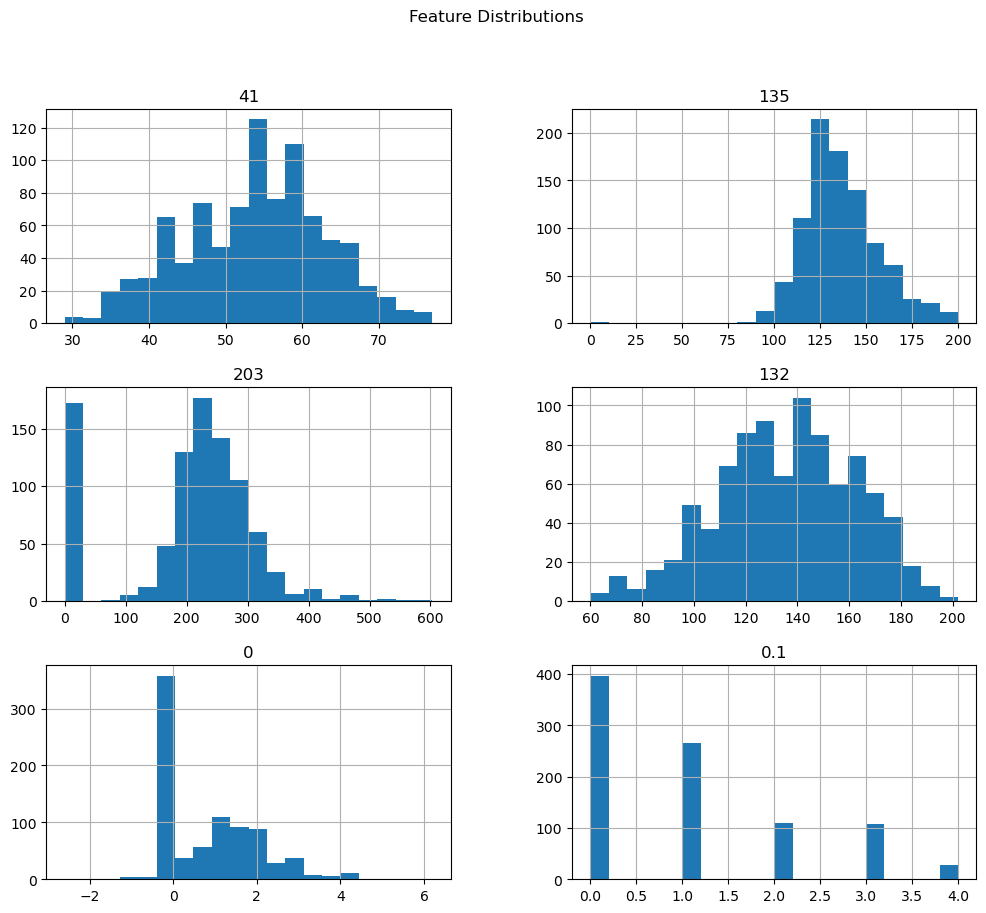

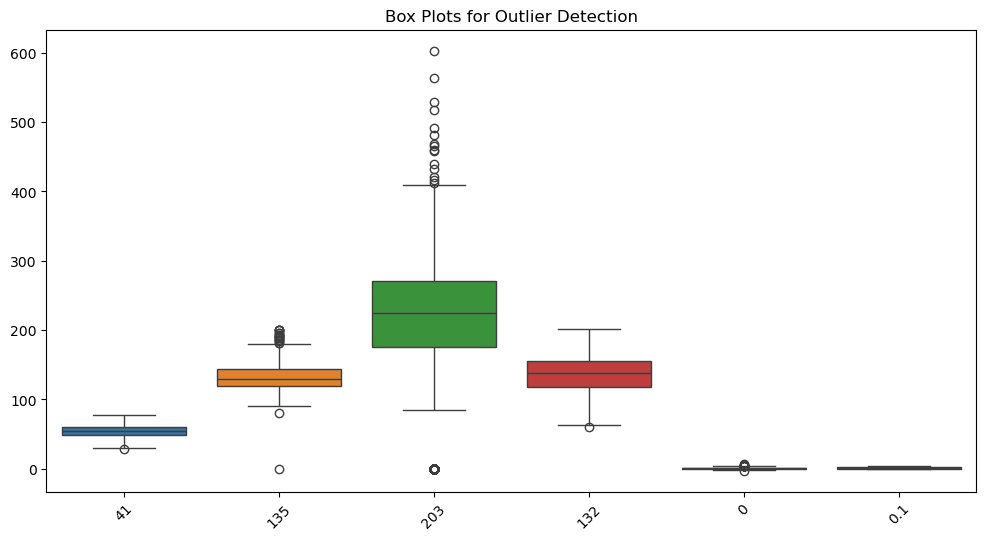

In [8]:
# Select numeric columns for visualization
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Histograms to see distributions
df[numeric_cols].hist(figsize=(12, 10), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

# Box plots to identify outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Box Plots for Outlier Detection")
plt.show()

In [10]:
import pandas as pd

# 1. Identify categorical columns that need encoding
# Based on your CSV, likely candidates are: 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'
categorical_cols = ['Male', 'atypical angina', 'FALSE', 'normal', 'flat', 'fixed defect'] 
# Note: You should check your specific column names using df.columns

# 2. Convert categorical data to numeric using get_dummies
# 'drop_first=True' is recommended to avoid multicollinearity (the "dummy variable trap")
df_encoded = pd.get_dummies(df, drop_first=True)

# 3. Now you can check the info to ensure everything is numeric
print(df_encoded.info())

# 4. Now you can safely calculate correlation or train your model
correlation_matrix = df_encoded.corr()

<class 'pandas.core.frame.DataFrame'>
Index: 906 entries, 0 to 905
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   41                               906 non-null    float64
 1   135                              906 non-null    float64
 2   203                              906 non-null    float64
 3   132                              906 non-null    float64
 4   0                                844 non-null    float64
 5   0.1                              906 non-null    float64
 6   Male_Male                        906 non-null    bool   
 7   atypical angina_atypical angina  906 non-null    bool   
 8   atypical angina_non-anginal      906 non-null    bool   
 9   atypical angina_typical angina   906 non-null    bool   
 10  FALSE_True                       906 non-null    bool   
 11  normal_normal                    906 non-null    bool   
 12  normal_st-t abnormality    

### 3. Feature Engineering:

In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Load data correctly (ensure headers are assigned)
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal', 'num']
df = pd.read_csv('heart_disease_combined.csv', skiprows=1006, names=columns)

# 2. Handle Missing Values
# Fill numerical missing values with the median
df = df.fillna(df.median(numeric_only=True))
# Fill categorical missing values with the mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Transform Target Variable (Binary Classification)
# Convert 0 to 0 (No Disease), and 1-4 to 1 (Presence of Disease)
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# 4. Encoding Categorical Variables
# Drop 'first' to avoid multicollinearity
df = pd.get_dummies(df, drop_first=True)

# 5. Scaling Numerical Features
scaler = StandardScaler()
# Select columns that are not binary dummy variables
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Feature Engineering complete. Preview of processed data:")
print(df.head())

Feature Engineering complete. Preview of processed data:
        age  trestbps      chol    fbs    thalch   oldpeak  num  sex_Male  \
0  0.365281  0.353982 -0.107426  False  0.464099 -0.424132    0      True   
1 -0.208059 -0.775362 -0.163443  False  2.106704 -0.818039    0      True   
2  0.365281 -1.186032 -0.023401  False -0.396314  0.659113    0      True   
3  1.397294  1.380658  0.228674  False  0.073002  1.446928    0      True   
4  0.250613 -0.159356  0.676806  False -0.318094  0.166729    0      True   

   cp_atypical angina  cp_non-anginal  cp_typical angina  restecg_normal  \
0               False           False              False            True   
1               False           False               True           False   
2               False           False              False            True   
3               False           False              False           False   
4               False            True              False            True   

   restecg_st-t abnorma

C:\Users\ibran\AppData\Local\Temp\ipykernel_22896\4065962302.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


### 4. Decision Tree Classification:

In [13]:
import pandas as pd

# Define the correct column names based on your dataset description
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
    'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal', 'num'
]

# Load the file, skipping the header/description section (the first 1005 lines)
# Use 'names' to explicitly set the correct headers
df = pd.read_csv('heart_disease_combined.csv', skiprows=1006, names=column_names)

# Now check the columns to confirm 'num' exists
print(df.columns)

# You can now safely access the 'num' column
print(df['num'].head())

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: num, dtype: float64


### 5. Hyperparameter Tuning:

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Load Data
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal', 'num']
df = pd.read_csv('heart_disease_combined.csv', skiprows=1006, names=column_names)

# 2. Preprocessing
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded = df_encoded.fillna(df_encoded.median())

# 3. Split
X = df_encoded.drop('num', axis=1)
y = df_encoded['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Fit the model (This creates 'clf')
# Using the best parameters found in the previous step
clf = DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_split=10, random_state=42)
clf.fit(X_train, y_train)

print("Success: 'clf' is now defined and trained.")

Success: 'clf' is now defined and trained.


### 6. Model Evaluation and Analysis:

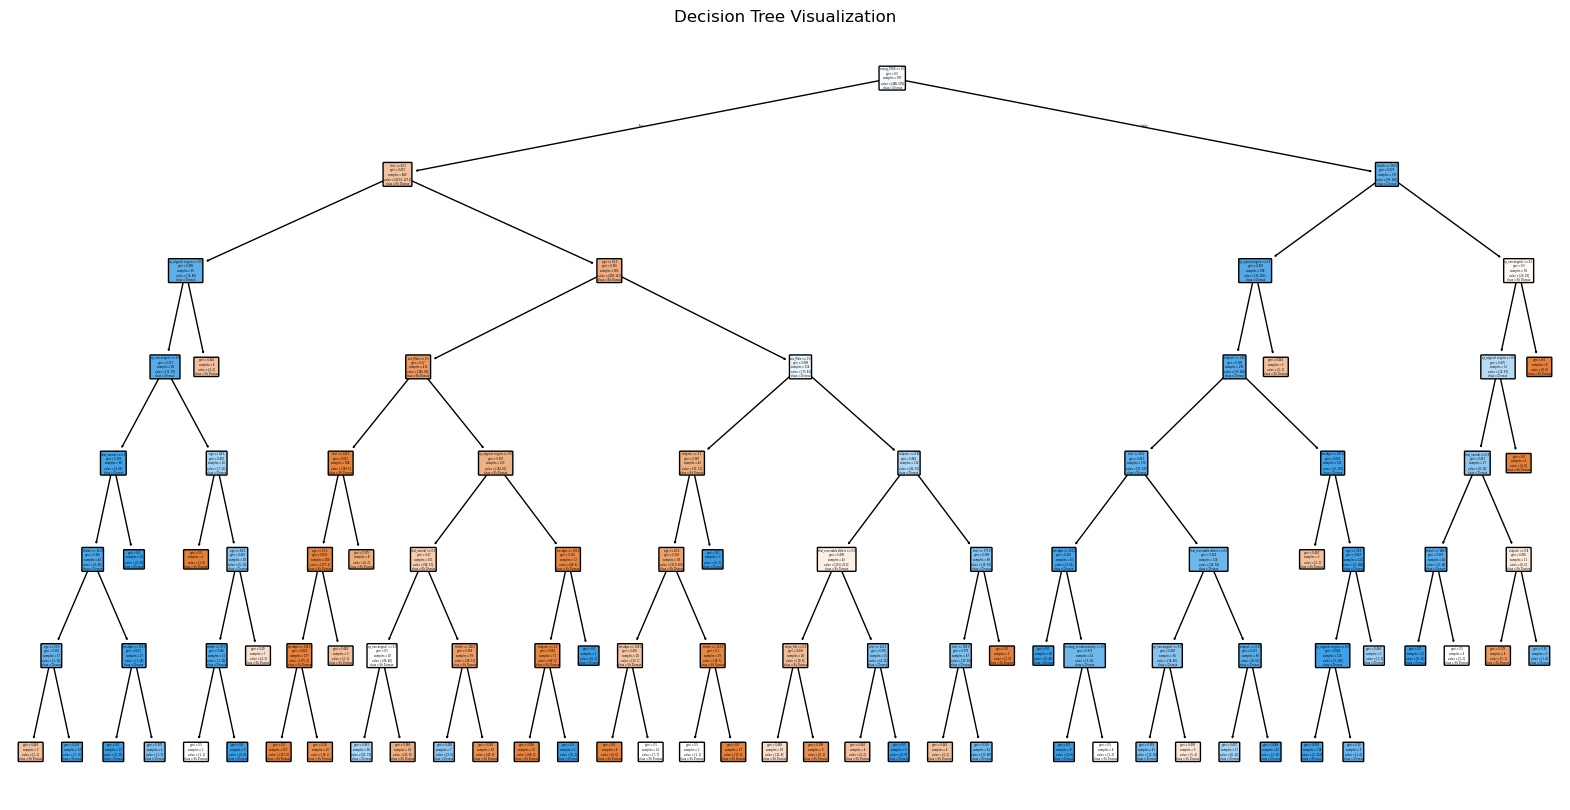

Top 5 Important Features:
       Feature  Importance
12  exang_TRUE    0.332791
2         chol    0.200243
0          age    0.117934
5     sex_Male    0.062933
3       thalch    0.057807


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Load and Prepare Data
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal', 'num']
df = pd.read_csv('heart_disease_combined.csv', skiprows=1006, names=column_names)
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded = df_encoded.fillna(df_encoded.median())

X = df_encoded.drop('num', axis=1)
y = df_encoded['num']

# 2. Train with Best Parameters
clf = DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_split=10, random_state=42)
clf.fit(X, y)

# 3. Visualize Tree
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=['No Disease', 'Disease'], filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

# 4. Feature Importance
importance = pd.DataFrame({'Feature': X.columns, 'Importance': clf.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)
print("Top 5 Important Features:")
print(importance.head(5))

### Interview Questions:

##### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
Hyperparameters are the configuration settings you define before training begins. They control the tree's growth and are critical for balancing the bias-variance tradeoff—specifically, preventing the model from overfitting (memorizing the training data) or underfitting (being too simple).

max_depth: This limits the maximum number of levels the tree can grow.

Effect: High depth allows the model to learn complex patterns but risks capturing noise (overfitting). Low depth forces the model to be simple, which may miss underlying trends (underfitting).

min_samples_split: The minimum number of samples required to split an internal node.

Effect: Increasing this prevents the tree from creating splits based on very small groups, which makes the model more robust and generalizable.

min_samples_leaf: The minimum number of samples required to be at a leaf node.

Effect: Like min_samples_split, this prevents the creation of leaves that represent individual, isolated data points, effectively "smoothing" the model's predictions.

criterion: The function used to measure the quality of a split (e.g., gini or entropy).

Effect: While the choice often has a minor impact, gini is computationally faster, whereas entropy may produce slightly more balanced trees.

##### 2. What is the difference between Label Encoding and One-Hot Encoding?
Both are techniques used to convert categorical (text) data into numeric data, which is a requirement for most machine learning algorithms. The choice between them depends on the nature of your data.

| Feature | Label Encoding | One-Hot Encoding |
| :--- | :--- | :--- |
| **How it works** | Assigns a unique integer (0, 1, 2, ...) to each category. | Creates a new binary column for every category (e.g., Is_Male, Is_Female). |
| **Best Use Case** | **Ordinal data** where there is a clear rank or order (e.g., "Low", "Medium", "High"). | **Nominal data** where there is no inherent order (e.g., "Male", "Female", "Red", "Blue"). |
| **Potential Risk** | The model may incorrectly interpret the assigned integers as having a mathematical order (e.g., 2 > 1). | Can cause "dimensionality explosion" if the feature has a very large number of unique categories. |